## Planning Algorithms in AI 
## PS2: Sampling-based Planning

Student: Olga Tiupina

Problem: 

## Task I: Visualization

In [1]:
import numpy as np
import pickle
from environment import State, ManipulatorEnv
from rrt import RRTPlanner
from video_util import animate_plan
import matplotlib.pyplot as plt


### A

In [2]:
# load data
with open("data.pickle", "rb") as f:
    data = pickle.load(f)

start_state = State(np.array(data["start_state"]))
goal_state = State(np.array(data["goal_state"]))

env = ManipulatorEnv(
    obstacles=np.array(data["obstacles"]),
    initial_state=start_state,
    collision_threshold=data["collision_threshold"]
)

print("Start state angles:", start_state.angles)
print("Start state joints:")
print(start_state.joints)
print("Goal state angles:", goal_state.angles)
print("Goal state joints:")
print(goal_state.joints)


Start state angles: [0. 0. 0. 0.]
Start state joints:
[[0. 0.]
 [1. 0.]
 [2. 0.]
 [3. 0.]
 [4. 0.]]
Goal state angles: [-180.  -60.   72.  -60.]
Goal state joints:
[[ 0.00000000e+00  0.00000000e+00]
 [-1.00000000e+00 -1.22464680e-16]
 [-1.50000000e+00  8.66025404e-01]
 [-2.47814760e+00  6.58113713e-01]
 [-3.14727821e+00  1.40125854e+00]]


In [ ]:
# function to visualize a given state
def visualize_state(env, state, title="State"):
    env.state = state
    plt.figure(figsize=(6, 6))
    env.render(plt_show=False)
    plt.title(title)
    plt.show()

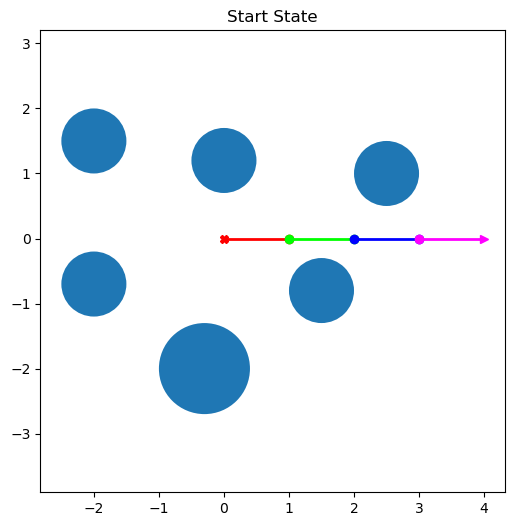

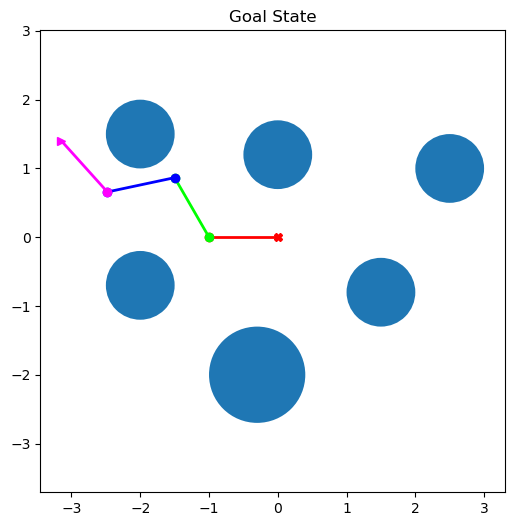

In [ ]:
visualize_state(env, start_state, "Start State")
visualize_state(env, goal_state, "Goal State")


### Комментарий к пункту A
В предыдущем задании PS1 пространство ориентаций было **дискретным** (0, 45, 90, 135).  
В этом задании оно **непрерывное**, θ ∈ (−180°, 180°], что приводит к:

- бесконечному пространству конфигураций,
- более плавным и реалистичным движениям робота,
- необходимости использовать методы поиска в непрерывном пространстве (RRT, RRT\*\*, random sampling),
- более точной проверке коллизий.

То есть задача становится существенно сложнее, но и ближе к реальным роботам.


### B

In [30]:
def random_state():
    q = np.random.uniform(-180, 180, size=4) # создает массив из 4 случайных чисел (углы в градусах для 4 суставов робота)
    return State(q)

# random_states = [random_state() for _ in range(4)] # генератор списка
random_states = []
for i in range(4):
    state = random_state()
    while i % 2 == 0 and env.check_collision(state):
        state = random_state()
    while i % 2 != 0 and not env.check_collision(state):
        state = random_state()
    random_states.append(state)



=== Random state 1 ===
Angles: [  7.12662514   5.97125541 139.59781345  70.92500164]
Collision: False


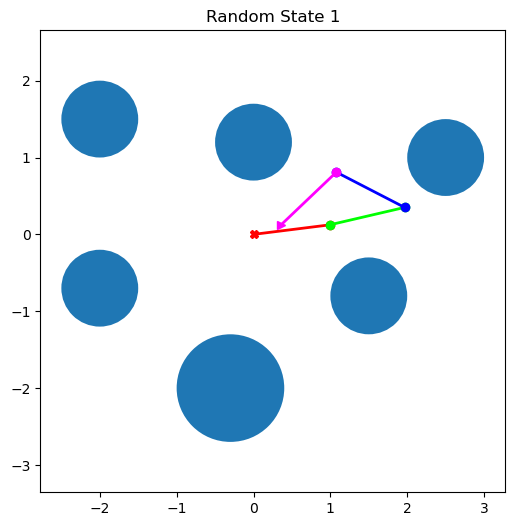


=== Random state 2 ===
Angles: [-96.30522435  29.30623436 125.19058643  85.90358193]
Collision: True


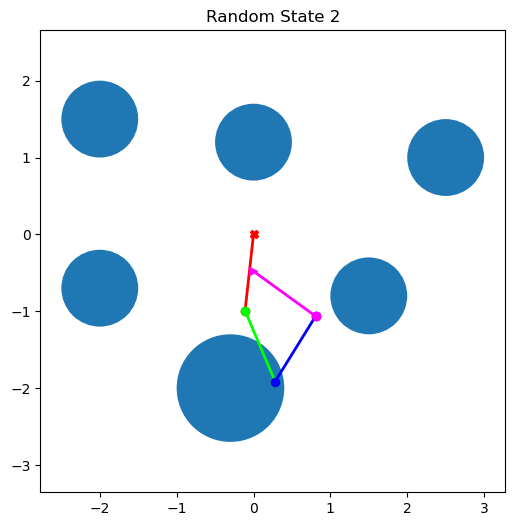


=== Random state 3 ===
Angles: [ -39.01920774 -155.58470272   54.91313657 -115.99761988]
Collision: False


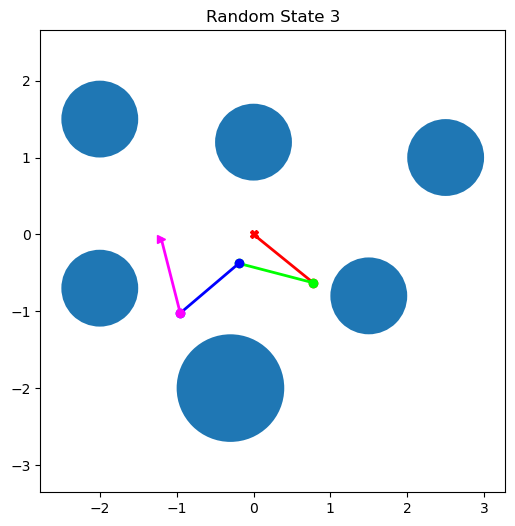


=== Random state 4 ===
Angles: [  68.07902468 -145.53023265  -40.4507707   -61.51518731]
Collision: True


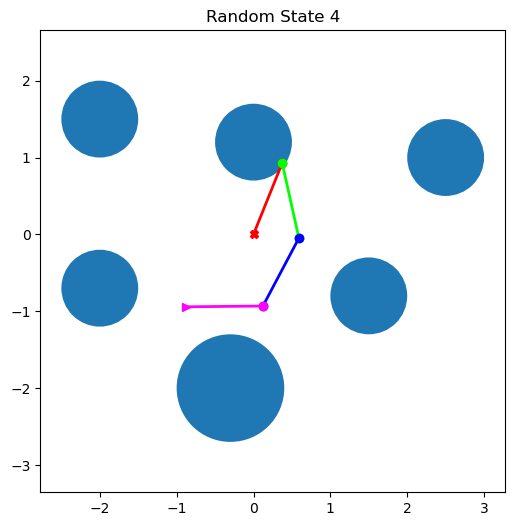

In [31]:
for i, st in enumerate(random_states, 1):
    print(f"\n=== Random state {i} ===")
    print("Angles:", st.angles)
    
    collision = env.check_collision(st)
    print("Collision:", collision)
    
    visualize_state(env, st, f"Random State {i}")


### Комментарий к пункту B

При визуализации заметно:

- Некоторые случайные конфигурации приводят к **столкновению**,
  когда звенья подходят ближе, чем `collision_threshold` к препятствию.
- Функция `check_collision()` корректно отлавливает:
  - касания концами звена,
  - пересечение середины звена (с помощью проекции на отрезок),
  - приближение к окружности.
- Пересечение звеньев **между собой** допускается — и это видно на рисунках.
- Геометрия манипулятора соответствует последовательному SE(2)-умножению, и изменения углов хорошо видны.

Таким образом, визуализация подтверждает корректность расчётов и проверки коллизий.


## Task II: Rapidly-exploring Random Trees (RRT)